In [2]:
from google.colab import files

# Open file picker and upload
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


Successfully located 'IMDB Dataset.csv'. Loading data...
Loaded 10000 records for training.
Training Logistic Regression model on your Kaggle data...

--- MODEL PERFORMANCE EVALUATION ---
Accuracy Score: 87.40%

Detailed Classification Report:

              precision    recall  f1-score   support

    Negative       0.90      0.85      0.87       999
    Positive       0.85      0.90      0.88      1001

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



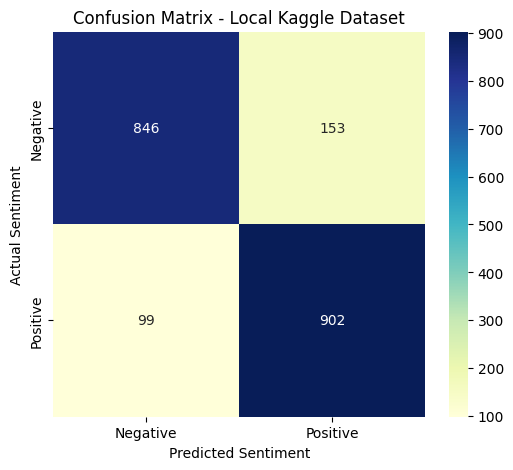


--- INTERACTIVE SENTIMENT PREDICTOR ---

Your Review: 'This movie had a fantastic plot and brilliant acting!'
Predicted Sentiment: 😊 POSITIVE
Model Confidence: 69.36%


In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# ==========================================
# STEP 1: Load Your Local Kaggle File
# ==========================================
# Make sure the string matches your file's exact name and path
csv_file_path = "IMDB Dataset.csv"

if not os.path.exists(csv_file_path):
    raise FileNotFoundError(
        f"Could not find '{csv_file_path}'. "
        f"Make sure the CSV file is in the exact same folder as this script!"
    )

print(f"Successfully located '{csv_file_path}'. Loading data...")
full_df = pd.read_csv(csv_file_path)

# Sampling 10,000 rows for an optimal balance of training accuracy and speed
df = full_df.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Loaded {df.shape[0]} records for training.")

# ==========================================
# STEP 2: Data Preprocessing
# ==========================================
# Clean HTML tags (like <br />) that are common in Kaggle text datasets
df["review"] = df["review"].str.replace(r"<[^>]*>", " ", regex=True)

# Map text labels ('positive' / 'negative') to binary numbers (1 / 0)
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

# Split into Features (X) and Target (y)
X = df["review"]
y = df["sentiment"]

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Text Vectorization using TF-IDF
# We use max_features=10000 to keep the most meaningful words and drop noise
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


# ==========================================
# STEP 3: Model Training
# ==========================================
print("Training Logistic Regression model on your Kaggle data...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


# ==========================================
# STEP 4: Accuracy Calculation & Evaluation
# ==========================================
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 45)
print("--- MODEL PERFORMANCE EVALUATION ---")
print("=" * 45)
print(f"Accuracy Score: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))


# ==========================================
# STEP 5: Result Visualization
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.title("Confusion Matrix - Local Kaggle Dataset")
plt.ylabel("Actual Sentiment")
plt.xlabel("Predicted Sentiment")
plt.show()


# ==========================================
# STEP 6: Colab Native Form Input (No Freezing)
# ==========================================
print("\n" + "=" * 45)
print("--- INTERACTIVE SENTIMENT PREDICTOR ---")
print("=" * 45)


def predict_user_sentiment(user_text):
    if not user_text.strip():
        print("\nPlease type a review in the form field on the right!")
        return

    # Pass the text through our trained vectorizer pipeline
    transformed_input = vectorizer.transform([user_text])
    prediction = model.predict(transformed_input)[0]
    probability = model.predict_proba(transformed_input)[0]

    sentiment = "😊 POSITIVE" if prediction == 1 else "😡 NEGATIVE"
    confidence = (
        probability[1] if prediction == 1 else probability[0]
    ) * 100

    print(f"\nYour Review: '{user_text}'")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Model Confidence: {confidence:.2f}%")


# @markdown ---
# @markdown ### 📝 Type your review here and press Ctrl+Enter (or click Play):
user_review = "This movie had a fantastic plot and brilliant acting!"  # @param {type:"string"}
# @markdown ---

predict_user_sentiment(user_review)